#### 손글씨 MNIST

In [1]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) =\
    keras.datasets.mnist.load_data()

2026-07-07 10:35:42.724103: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
# 데이터 확인
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [3]:
# target 분류 확인
import numpy as np

np.unique(train_target, return_counts= True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

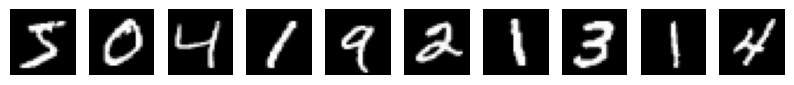

In [4]:
# train_input 모양 10개만 출력
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize = (10, 10))

for i in range(10) :
    axs[i].imshow(train_input[i], cmap='gray')
    axs[i].axis('off')
plt.show()

----
#### 개인 실습 코드 (오류 발생할 수 있음)

----
#### 인공신경망 확인
: 몇번의 Epoch가 최대인지 확인

In [5]:
# 데이터 정규화 및 2차 행렬로 만들기
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1,28*28)
train_scaled.shape

(60000, 784)

In [6]:
# train / validation datasets 분리
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size= 0.2,
        random_state= 42
    )

In [7]:
# 확인
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [8]:
# 인공신경망 model 생성 : input 층 -> 출력층 -> 활성함수
from tensorflow.keras.layers import Input

model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(10, activation= 'softmax'))

In [9]:
# 손실함수
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [10]:
# 모델 훈련 (epoch 조절)
# fit 만 epoch를 바꾸면서 하면 계속 누적되니까 모델 생성부터 다시 할 수 있도록 해야함
epochs_num = [5, 10, 15, 20, 50, 100]
scores = []

for epoch in epochs_num:
    model = keras.Sequential()
    model.add(Input(shape=(784,)))
    model.add(keras.layers.Dense(10, activation= 'softmax'))

    model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

    model.fit(train_scaled, train_target, epochs= epoch)
    eval = model.evaluate(val_scaled, val_target)[1]
    print(f"epoch : {epoch} -> score : {eval}")
    scores.append(eval)

print(epochs_num, scores)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8749 - loss: 0.4679
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9125 - loss: 0.3119
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9194 - loss: 0.2949
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9218 - loss: 0.2869
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9240 - loss: 0.2823
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9233 - loss: 0.2872
epoch : 5 -> score : 0.9233333468437195
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8764 - loss: 0.4670
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9128 - loss: 0.3122
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9180 - loss: 0.2949
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9211 - loss: 0.2870
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2818
Epoch 6/10

KeyboardInterrupt: 

In [ ]:
# 5번으로 테스트 (validation 결과 중 제일 좋은거 test)
model.fit(train_scaled, train_target, epochs= 5)
print(model.evaluate(train_scaled, train_target))
print(model.evaluate(val_scaled, val_target))

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9398 - loss: 0.2535
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9397 - loss: 0.2540
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9385 - loss: 0.2538
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9399 - loss: 0.2533
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9395 - loss: 0.2538
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9408 - loss: 0.2474
[0.24736720323562622, 0.940833330154419]
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9192 - loss: 0.3610
[0.36099007725715637, 0.9191666841506958]


> 구분선 밑으로 혼자 짠거라 맹신하지 마십시요